# Energy Distribution Patterns

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

/home/sriney/miniconda3/envs/est_proj/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


--- Correlation of Predictors with Power Demand ---
Power_Demand         1.000000
Temperature          0.469700
Dew_Point            0.285409
Wind_speed           0.252669
Year                 0.248182
Hour                 0.223219
Wind_direction       0.102651
Month                0.044792
Day                  0.025972
Minute               0.002123
Relative_Humidity   -0.176559
Pressure            -0.404449
Name: Power_Demand, dtype: float64

(Values close to 1.0 or -1.0 indicate a strong relationship)



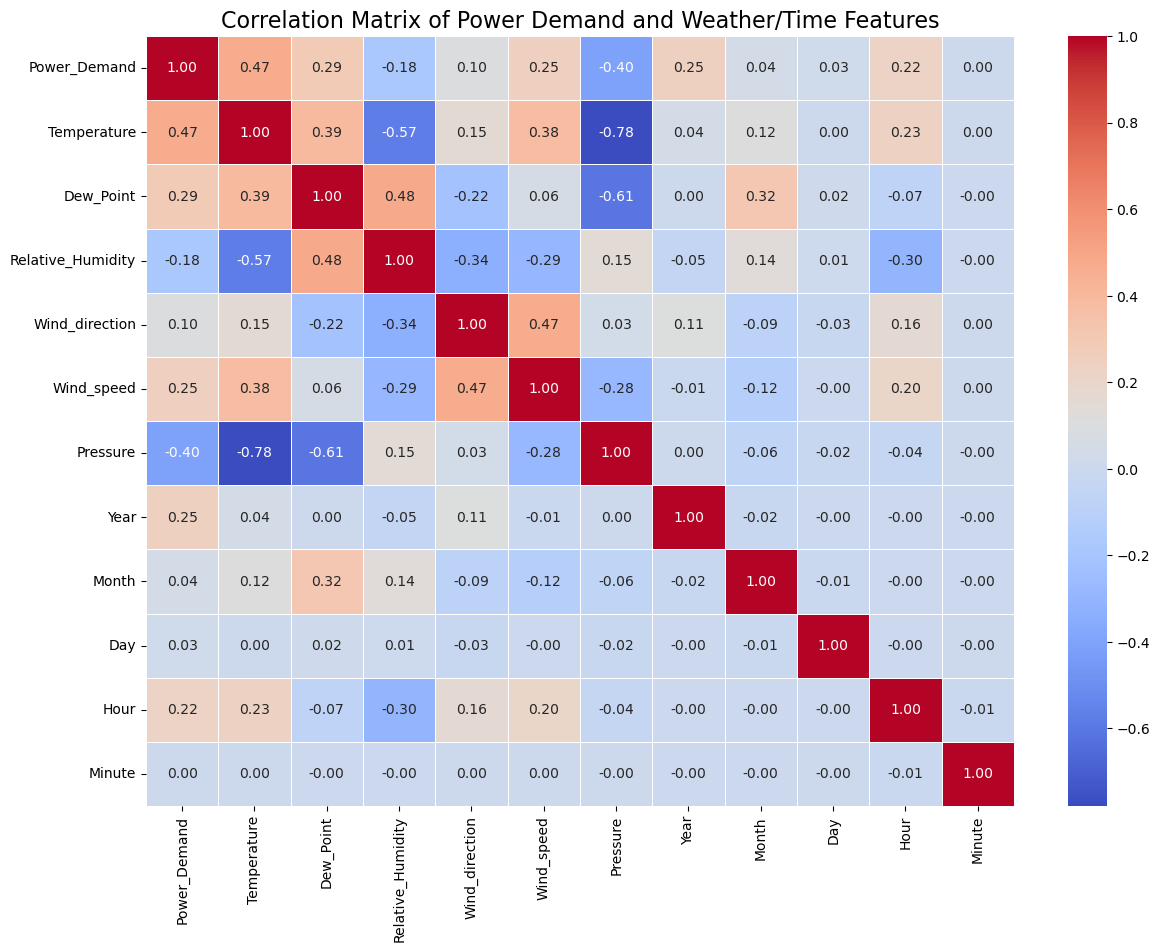

In [2]:


# --- 1. Load Your Data ---
# Replace 'your_file.csv' with the actual path to your CSV file.
try:
    df = pd.read_csv('Data/EST_Project_5min_Dataset.csv')
except FileNotFoundError:   
    print("Error: Make sure 'your_file.csv' is in the same directory as the script or provide the full path.")
    exit()


columns_for_correlation = [
    'Power_Demand', 'Temperature', 'Dew_Point', 'Relative_Humidity',
    'Wind_direction', 'Wind_speed', 'Pressure', 'Year', 'Month', 'Day',
    'Hour', 'Minute'
]
df_corr = df[columns_for_correlation]

# --- 3. Calculate the Correlation Matrix ---
# The .corr() method calculates the Pearson correlation coefficient between all pairs of columns.
# The result is a DataFrame where the rows and columns are the variable names.
correlation_matrix = df_corr.corr()

# --- 4. Analyze Correlation with the Target Variable ---
# We are most interested in how each predictor relates to 'Power_Demand'.
# Let's isolate that column from the matrix and sort it.
target_correlation = correlation_matrix['Power_Demand'].sort_values(ascending=False)

print("--- Correlation of Predictors with Power Demand ---")
print(target_correlation)
print("\n(Values close to 1.0 or -1.0 indicate a strong relationship)\n")


# --- 5. Visualize the Full Correlation Matrix with a Heatmap ---
# A heatmap is an excellent way to see the relationships visually.
plt.figure(figsize=(14, 10))  # Set the size of the figure for better readability
sns.heatmap(
    correlation_matrix,
    annot=True,          # Show the correlation values on the map
    cmap='coolwarm',     # Use a color map that's good for correlations (red=positive, blue=negative)
    fmt=".2f",           # Format the numbers to two decimal places
    linewidths=.5
)
plt.title('Correlation Matrix of Power Demand and Weather/Time Features', fontsize=16)
plt.show()

--- Starting Phase 1: Exploratory Data Analysis ---
Displaying overall power demand from 2021-2024...


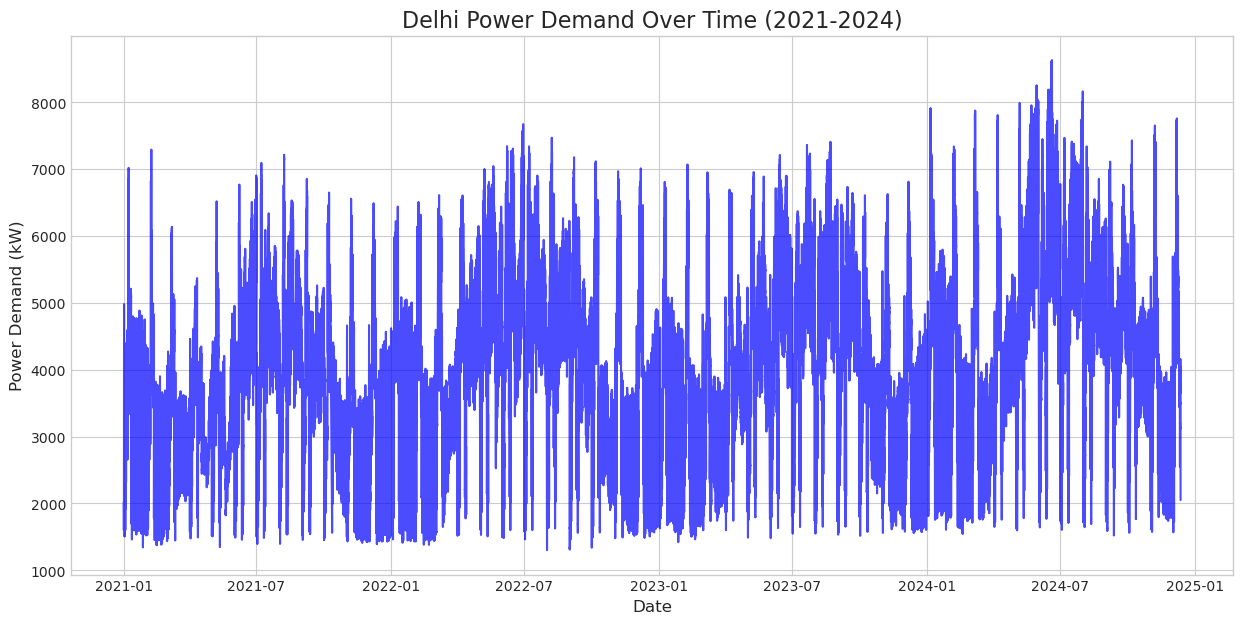

Displaying cyclical demand patterns (daily, weekly, monthly)...


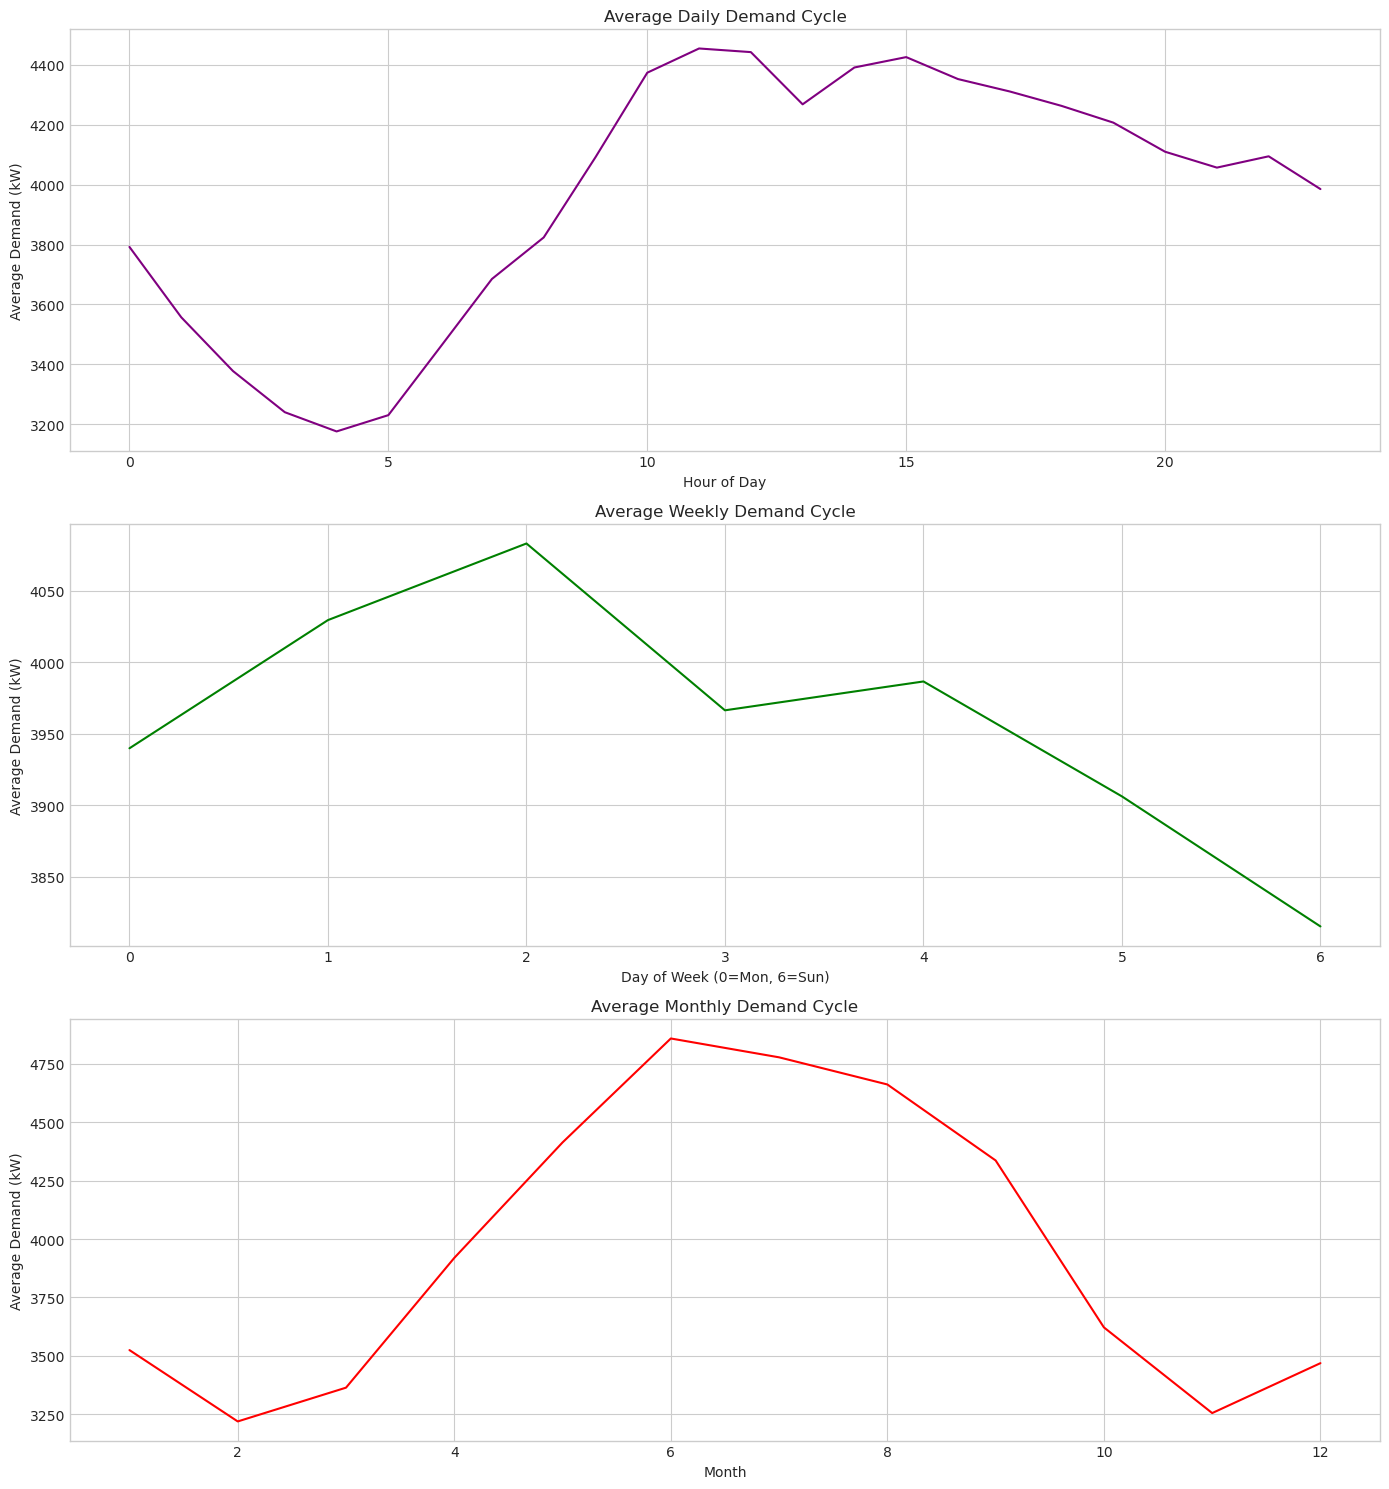

Displaying scatter plot of Temperature vs. Power Demand...


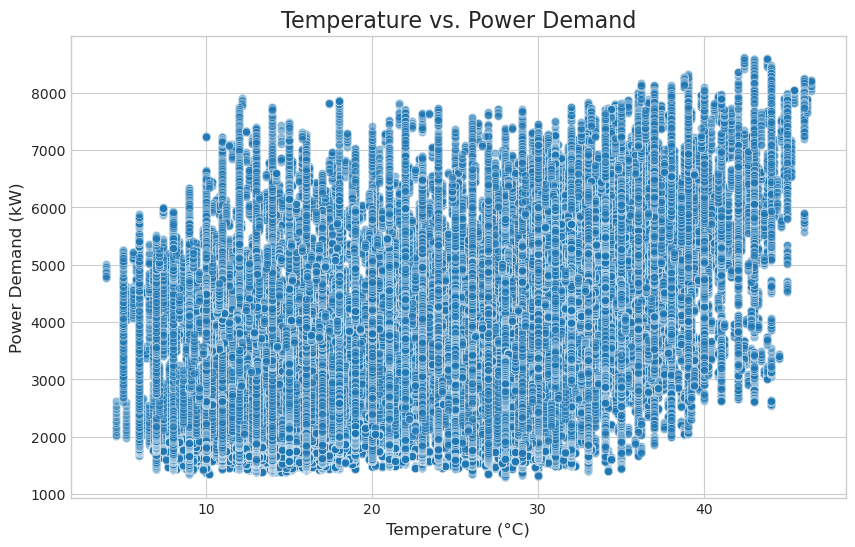

--- EDA Phase Complete ---

--- Starting Phase 2: Feature Engineering ---
Created new features: day_of_week, day_of_year, quarter, is_weekend, lag, and rolling mean.
--- Feature Engineering Phase Complete ---

--- Starting Phase 3: Model Building ---
Data split into training (298347 rows) and testing (94539 rows).
Training Linear Regression model...
Linear Regression training complete.
Training XGBoost model... (This may take a few moments)
XGBoost training complete.
--- Model Building Phase Complete ---

--- Starting Phase 4: Model Evaluation ---
--- Model Performance Metrics ---
Linear Regression - MAE: 501.52 kW, RMSE: 690.08 kW
XGBoost - MAE: 264.49 kW, RMSE: 384.98 kW
------------------------------

Displaying forecast visualization for a sample week in July 2024...


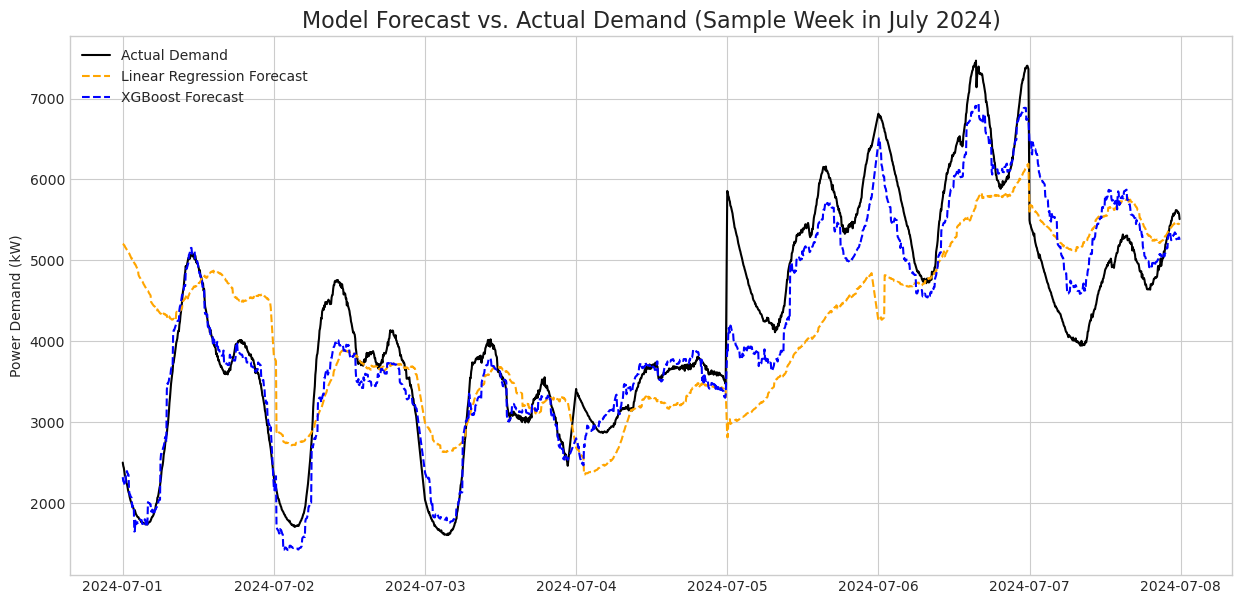

Displaying feature importance from the XGBoost model...


<Figure size 1200x800 with 0 Axes>

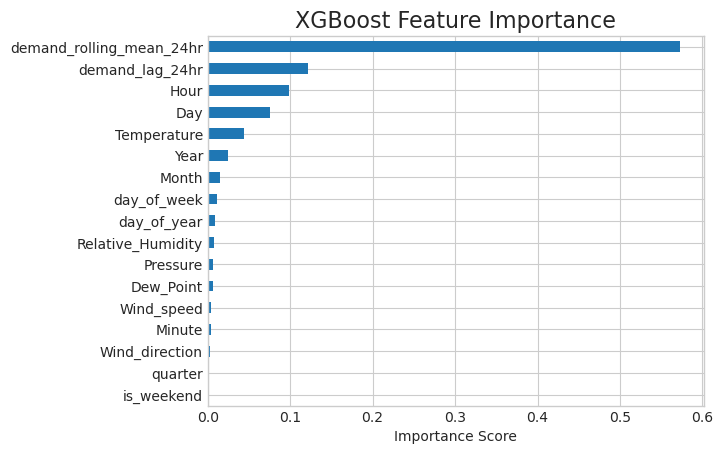

--- Model Evaluation Phase Complete ---

Project script finished successfully!


In [4]:


# --- Configuration ---
# Set the file path for your dataset
FILE_PATH = 'Data/EST_Project_5min_Dataset.csv'
plt.style.use('seaborn-v0_8-whitegrid') # A nice style for the plots


# --- Load Data Function ---
def load_data(filepath):
    """Loads and preprocesses the time-series data."""
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print(f"Error: The file was not found at {filepath}")
        print("Please make sure the file path is correct and the file is in the right directory.")
        return None

    # Convert 'Date_Time' to a proper datetime object
    df['Date_Time'] = pd.to_datetime(df['Date_Time'], format='%d-%m-%Y %H:%M')
    # Set the datetime column as the index, which is standard for time-series analysis
    df.set_index('Date_Time', inplace=True)
    # The 'Sl.No' column is not needed
    df.drop('Sl.No', axis=1, inplace=True)
    return df

# --- PHASE 1: EXPLORATORY DATA ANALYSIS (EDA) ---
def perform_eda(df):
    """Performs and visualizes key aspects of the data."""
    print("--- Starting Phase 1: Exploratory Data Analysis ---")

    # 1. Overall Time-Series Plot
    print("Displaying overall power demand from 2021-2024...")
    plt.figure(figsize=(15, 7))
    plt.plot(df.index, df['Power_Demand'], color='blue', alpha=0.7)
    plt.title('Delhi Power Demand Over Time (2021-2024)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Power Demand (kW)', fontsize=12)
    plt.show()

    # 2. Cyclical Patterns (Daily, Weekly, Monthly)
    print("Displaying cyclical demand patterns (daily, weekly, monthly)...")
    fig, axes = plt.subplots(3, 1, figsize=(14, 15))
    
    # Daily Cycle
    df.groupby(df.index.hour)['Power_Demand'].mean().plot(ax=axes[0], title='Average Daily Demand Cycle', color='purple')
    axes[0].set_xlabel('Hour of Day')
    axes[0].set_ylabel('Average Demand (kW)')
    
    # Weekly Cycle
    df.groupby(df.index.dayofweek)['Power_Demand'].mean().plot(ax=axes[1], title='Average Weekly Demand Cycle', color='green')
    axes[1].set_xlabel('Day of Week (0=Mon, 6=Sun)')
    axes[1].set_ylabel('Average Demand (kW)')

    # Monthly Cycle
    df.groupby(df.index.month)['Power_Demand'].mean().plot(ax=axes[2], title='Average Monthly Demand Cycle', color='red')
    axes[2].set_xlabel('Month')
    axes[2].set_ylabel('Average Demand (kW)')
    
    plt.tight_layout()
    plt.show()

    # 3. Scatter Plot of Temperature vs. Power Demand
    print("Displaying scatter plot of Temperature vs. Power Demand...")
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Temperature', y='Power_Demand', data=df, alpha=0.5)
    plt.title('Temperature vs. Power Demand', fontsize=16)
    plt.xlabel('Temperature (°C)', fontsize=12)
    plt.ylabel('Power Demand (kW)', fontsize=12)
    plt.show()
    print("--- EDA Phase Complete ---\n")


# --- PHASE 2: FEATURE ENGINEERING ---
def create_features(df):
    """Creates new features from the datetime index to improve model accuracy."""
    print("--- Starting Phase 2: Feature Engineering ---")
    df['day_of_week'] = df.index.dayofweek
    df['day_of_year'] = df.index.dayofyear
    df['quarter'] = df.index.quarter
    df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)

    # Lag feature (demand from 24 hours ago)
    # A 24hr lag for 5-min data means shifting by 24 * 12 = 288 steps
    df['demand_lag_24hr'] = df['Power_Demand'].shift(288)

    # Rolling mean feature (average demand over the last 24 hours)
    df['demand_rolling_mean_24hr'] = df['Power_Demand'].shift(1).rolling(window=288).mean()
    
    # Drop rows with NaN values created by lag/rolling features
    df.dropna(inplace=True)
    
    print("Created new features: day_of_week, day_of_year, quarter, is_weekend, lag, and rolling mean.")
    print("--- Feature Engineering Phase Complete ---\n")
    return df


# --- PHASE 3: MODEL BUILDING ---
def build_models(df):
    """Splits data and trains Linear Regression and XGBoost models."""
    print("--- Starting Phase 3: Model Building ---")
    
    # Define features (X) and target (y)
    features = [
        'Temperature', 'Dew_Point', 'Relative_Humidity', 'Wind_direction',
        'Wind_speed', 'Pressure', 'Year', 'Month', 'Day', 'Hour', 'Minute',
        'day_of_week', 'day_of_year', 'quarter', 'is_weekend',
        'demand_lag_24hr', 'demand_rolling_mean_24hr'
    ]
    target = 'Power_Demand'

    # Split data chronologically (no shuffling for time-series)
    train_end = '2023-12-31'
    X_train = df.loc[:train_end, features]
    y_train = df.loc[:train_end, target]
    X_test = df.loc[train_end:, features]
    y_test = df.loc[train_end:, target]

    print(f"Data split into training ({len(X_train)} rows) and testing ({len(X_test)} rows).")

    # Train Linear Regression (Baseline)
    print("Training Linear Regression model...")
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    lr_predictions = lr_model.predict(X_test)
    print("Linear Regression training complete.")

    # Train XGBoost (Advanced)
    print("Training XGBoost model... (This may take a few moments)")
    xgb_model = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        objective='reg:squarederror',
        early_stopping_rounds=50,
        n_jobs=-1  # Use all available CPU cores
    )
    xgb_model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  verbose=False)
    xgb_predictions = xgb_model.predict(X_test)
    print("XGBoost training complete.")
    print("--- Model Building Phase Complete ---\n")
    
    return y_test, lr_predictions, xgb_predictions, xgb_model, features


# --- PHASE 4: MODEL EVALUATION & INTERPRETATION ---
def evaluate_models(y_test, lr_preds, xgb_preds, xgb_model, features):
    """Evaluates models with metrics and visualizations."""
    print("--- Starting Phase 4: Model Evaluation ---")

    # Calculate and print error metrics
    lr_mae = mean_absolute_error(y_test, lr_preds)
    lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
    xgb_mae = mean_absolute_error(y_test, xgb_preds)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))

    print("--- Model Performance Metrics ---")
    print(f"Linear Regression - MAE: {lr_mae:.2f} kW, RMSE: {lr_rmse:.2f} kW")
    print(f"XGBoost - MAE: {xgb_mae:.2f} kW, RMSE: {xgb_rmse:.2f} kW")
    print("-" * 30 + "\n")

    # Visualize the forecast against actuals for a sample period
    print("Displaying forecast visualization for a sample week in July 2024...")
    results = pd.DataFrame({'Actual': y_test, 'LinearRegression': lr_preds, 'XGBoost': xgb_preds})
    
    # Plotting a sample week to avoid a cluttered graph
    sample_results = results.loc['2024-07-01':'2024-07-07']
    
    plt.figure(figsize=(15, 7))
    plt.plot(sample_results.index, sample_results['Actual'], label='Actual Demand', color='black')
    plt.plot(sample_results.index, sample_results['LinearRegression'], label='Linear Regression Forecast', color='orange', linestyle='--')
    plt.plot(sample_results.index, sample_results['XGBoost'], label='XGBoost Forecast', color='blue', linestyle='--')
    plt.title('Model Forecast vs. Actual Demand (Sample Week in July 2024)', fontsize=16)
    plt.ylabel('Power Demand (kW)')
    plt.legend()
    plt.show()

    # Feature Importance Plot for XGBoost
    print("Displaying feature importance from the XGBoost model...")
    feature_importance = pd.DataFrame({'importance': xgb_model.feature_importances_}, index=features)
    feature_importance.sort_values('importance', ascending=True, inplace=True)
    
    plt.figure(figsize=(12, 8))
    feature_importance.plot(kind='barh', legend=False)
    plt.title('XGBoost Feature Importance', fontsize=16)
    plt.xlabel('Importance Score')
    plt.show()
    print("--- Model Evaluation Phase Complete ---")


# --- Main Execution ---
if __name__ == '__main__':
    df = load_data(FILE_PATH)
    if df is not None:
        perform_eda(df)
        df_featured = create_features(df.copy()) # Use a copy to keep original df clean
        y_test, lr_preds, xgb_preds, xgb_model, features = build_models(df_featured)
        evaluate_models(y_test, lr_preds, xgb_preds, xgb_model, features)
        print("\nProject script finished successfully!")
